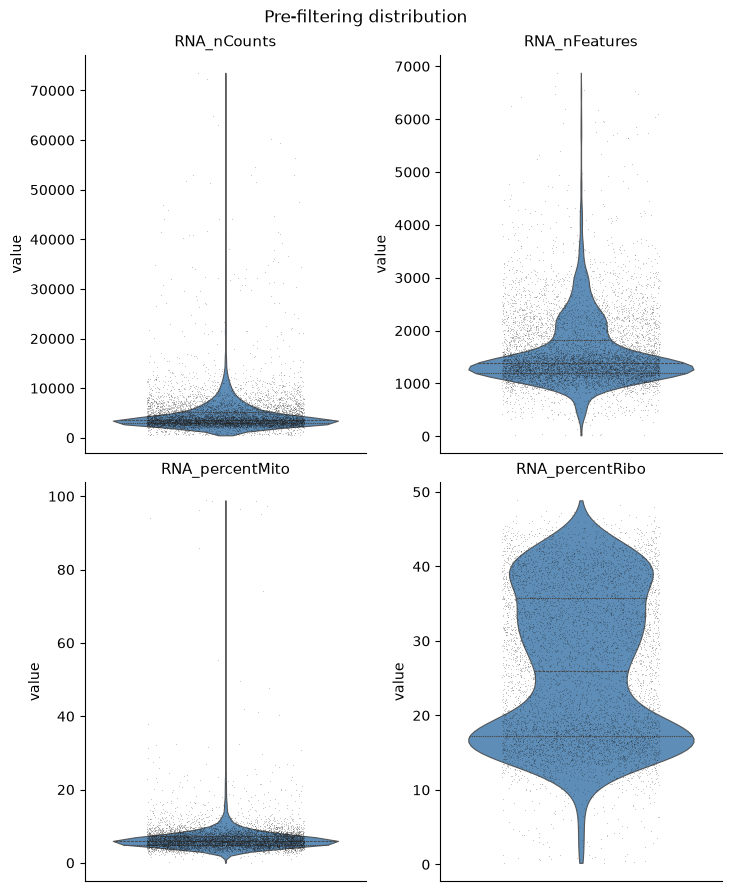

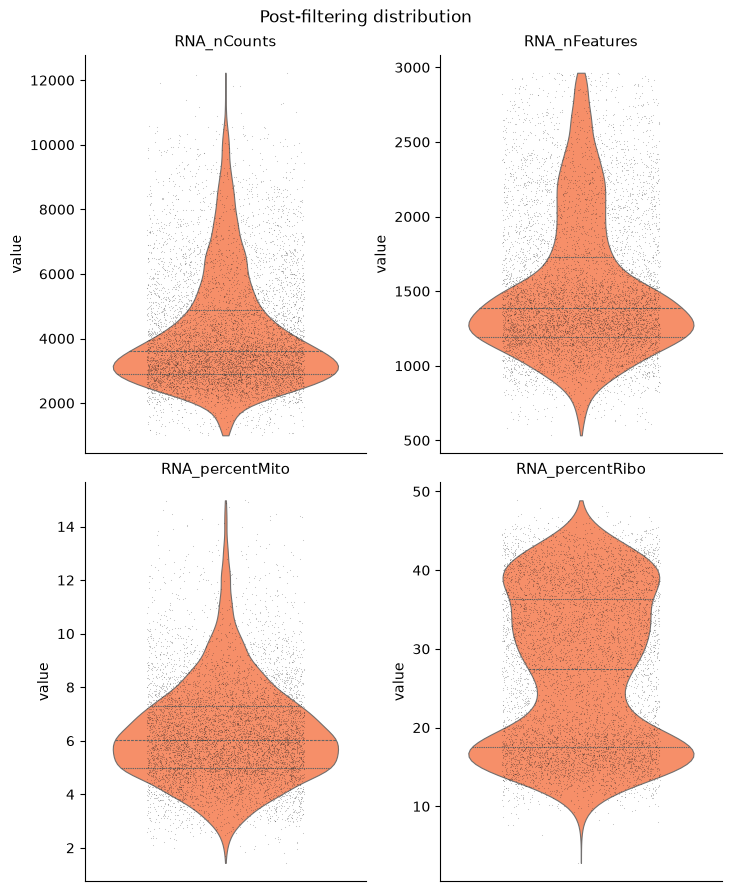

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_8K_pbmc_citeseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)
ds.auto_filter_cells()

In [2]:
ds.mark_hvgs(
    min_cells=20,
    top_n=1000,
    min_mean=-3,
    max_mean=2,
    max_var=6,
    show_plot=False,
)
ds.run_normalization(feat_key="hvgs")
ds.run_pca(dims=15)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=21)
ds.build_connectivity_map()
ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True)
ds.run_leiden_clustering(resolution=1)

In [3]:
adt_panel = ds.ADT.feats.to_pandas_dataframe(["names"])
is_control = adt_panel["names"].str.contains("control")
ds.ADT.feats.update_key(~is_control.values, "I")

normalized_adt = ds.run_normalization(
    from_assay="ADT",
    feat_key="I",
)
n_adt_features = int(
    ds.load_artifact(normalized_adt)["data"].shape[1]
)
ds.run_custom_reduction(
    np.eye(n_adt_features, dtype=np.float64),
    normalized_adt,
    from_assay="ADT",
)
ds.build_embedding_initialization(
    from_assay="ADT",
    n_centroids=100,
)
ds.build_ann_index(from_assay="ADT")
ds.query_neighbors(from_assay="ADT", k=21)
ds.build_connectivity_map(from_assay="ADT")
ds.run_umap(
    from_assay="ADT",
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
)
ds.run_leiden_clustering(from_assay="ADT", resolution=1)

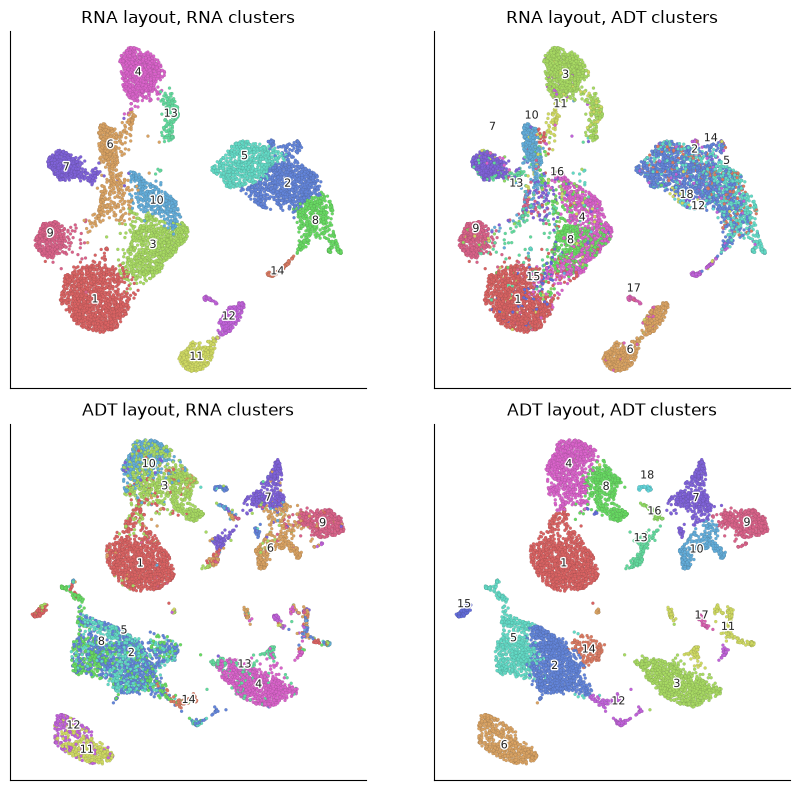

In [4]:
figure, axes = plt.subplots(2, 2, figsize=(9, 8))
modality_panels = (
    ("RNA layout, RNA clusters", "RNA_UMAP", "RNA_leiden_cluster"),
    ("RNA layout, ADT clusters", "RNA_UMAP", "ADT_leiden_cluster"),
    ("ADT layout, RNA clusters", "ADT_UMAP", "RNA_leiden_cluster"),
    ("ADT layout, ADT clusters", "ADT_UMAP", "ADT_leiden_cluster"),
)
for axis, (title, layout_key, color_by) in zip(
    axes.flat, modality_panels, strict=True
):
    ds.plots.embedding(
        layout_key=layout_key,
        color_by=color_by,
        point_size=5,
        legend_loc="on_data",
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()

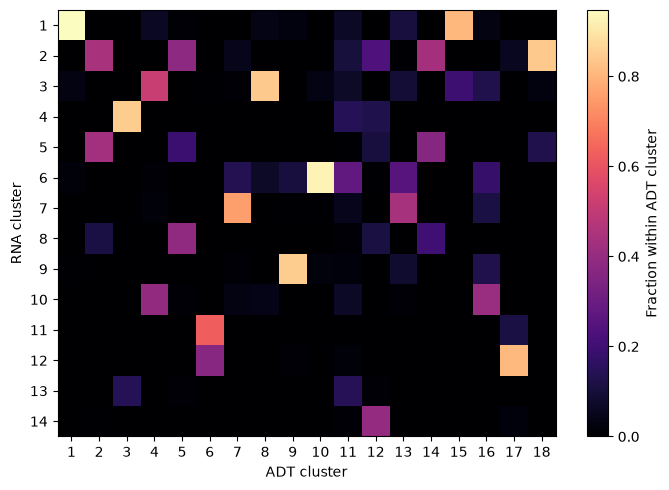

In [5]:
overlap = pd.crosstab(
    ds.cells.fetch("RNA_leiden_cluster"),
    ds.cells.fetch("ADT_leiden_cluster"),
    normalize="columns",
)

fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(overlap.to_numpy(), aspect="auto", cmap="magma")
ax.set(
    xlabel="ADT cluster",
    ylabel="RNA cluster",
    xticks=np.arange(overlap.shape[1]),
    yticks=np.arange(overlap.shape[0]),
    xticklabels=overlap.columns,
    yticklabels=overlap.index,
)
fig.colorbar(image, ax=ax, label="Fraction within ADT cluster")
fig.tight_layout()

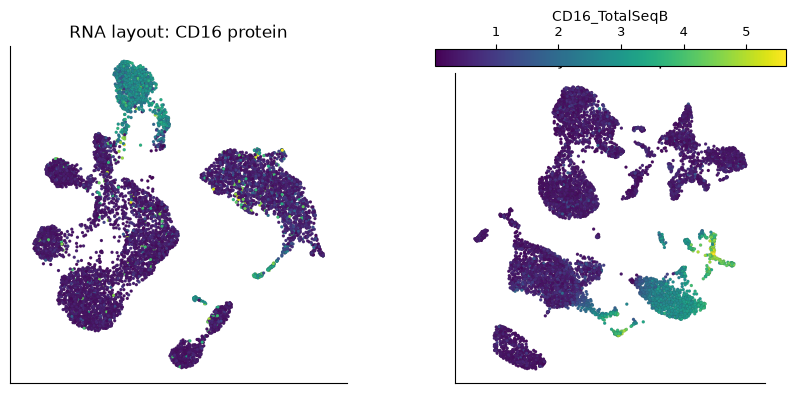

In [6]:
def compare_signal(feature, assay, label):
    figure, axes = plt.subplots(1, 2, figsize=(9, 4))
    for index, (axis, (layout_label, layout_key)) in enumerate(
        zip(
            axes,
            (("RNA layout", "RNA_UMAP"), ("ADT layout", "ADT_UMAP")),
            strict=True,
        )
    ):
        ds.plots.embedding(
            layout_key=layout_key,
            color_by=feature,
            from_assay=assay,
            point_size=5,
            show_legend=index == 1,
            show_titles=False,
            target=axis,
            show=False,
        )
        axis.set_title(f"{layout_label}: {label}")
    figure.tight_layout()
    return figure


compare_signal("CD16_TotalSeqB", "ADT", "CD16 protein");

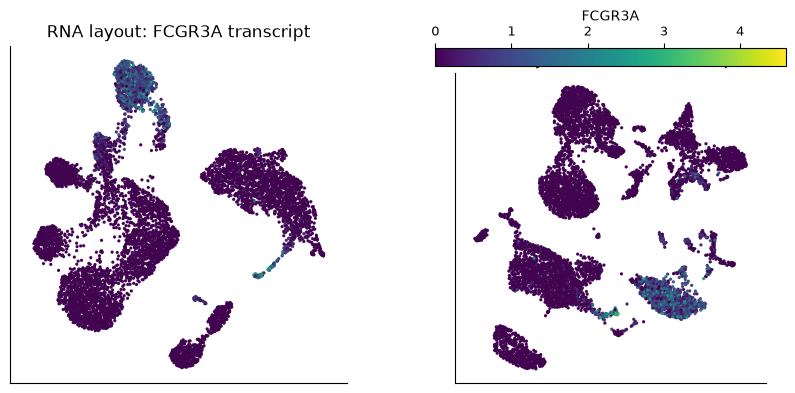

In [7]:
compare_signal("FCGR3A", "RNA", "FCGR3A transcript");

In [8]:
ds.integrate_assays(
    assays=["RNA", "ADT"],
    label="RNA+ADT_snn",
    method="snn",
)
ds.run_umap(
    integrated_graph="RNA+ADT_snn",
    n_epochs=500,
    spread=5,
    min_dist=0.5,
    parallel=True,
)
ds.run_leiden_clustering(
    integrated_graph="RNA+ADT_snn",
    resolution=1.75,
)

In [9]:
ds.integrate_assays(
    assays=["RNA", "ADT"],
    label="RNA+ADT_wnn",
    method="wnn",
)
ds.run_umap(
    integrated_graph="RNA+ADT_wnn",
    n_epochs=500,
    spread=5,
    min_dist=0.5,
    parallel=True,
)
ds.run_leiden_clustering(
    integrated_graph="RNA+ADT_wnn",
    resolution=1.75,
)

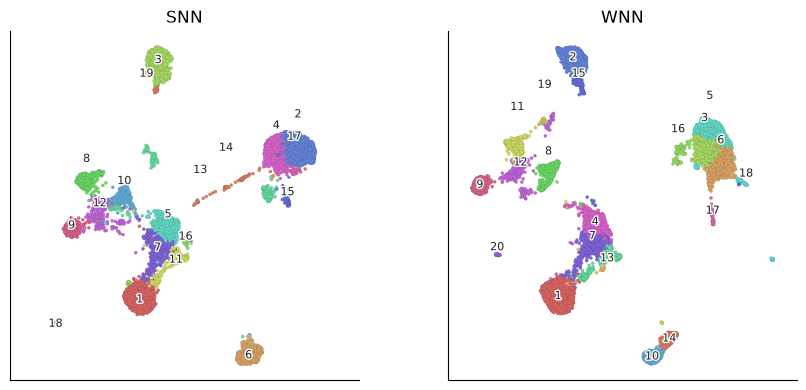

In [10]:
figure, axes = plt.subplots(1, 2, figsize=(9, 4))
integration_panels = (
    ("SNN", "RNA+ADT_snn_UMAP", "RNA+ADT_snn_leiden_cluster"),
    ("WNN", "RNA+ADT_wnn_UMAP", "RNA+ADT_wnn_leiden_cluster"),
)
for axis, (title, layout_key, color_by) in zip(
    axes, integration_panels, strict=True
):
    ds.plots.embedding(
        layout_key=layout_key,
        color_by=color_by,
        legend_loc="on_data",
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()